# Photometric Calibration

This notebook demonstrates how to perform photometric calibration using reference catalogs to convert instrumental magnitudes to standard magnitudes.

## 1. Load Data

Use `DataBrowser` to query and filter synced data for photometric analysis.


Filter data for:
- **Target**: T00528
- **Filter**: r-band
- **Pattern**: `*100.fits` (100-second exposures)


In [1]:
from ezphot.utils import DataBrowser
databrowser = DataBrowser('scidata')
databrowser.objname = 'T00528'
databrowser.filter = 'm600'
target_imgset = databrowser.search('*100.fits', 'science')
target_imglist = target_imgset.target_images

[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/*/m600/*100.fits'


Loading Science Images: 100%|██████████| 90/90 [00:00<00:00, 95.45it/s] 


(<Figure size 800x600 with 2 Axes>,
 <WCSAxes: title={'center': 'calib_7DT14_T00528_20250906_025855_m600_100.fits'}>)

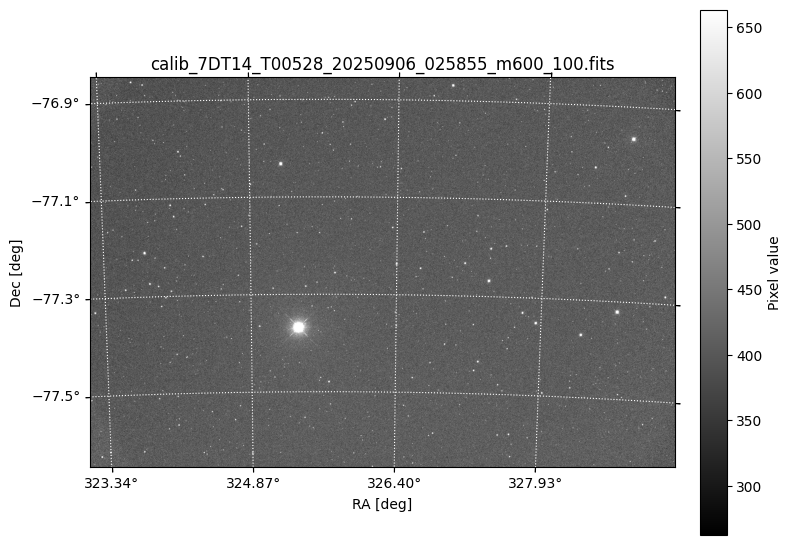

In [2]:
target_img = target_imglist[0]
target_img.show('coord')

## 2. Photometric Calibration

Convert instrumental magnitudes to standard magnitudes using reference catalogs. A photometric catalog is required - see the `Aperture Photometry` example. 

### 2.1. Load Source Catalog

Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/subbkg_calib_7DT14_T00528_20250906_025855_m600_100.fits


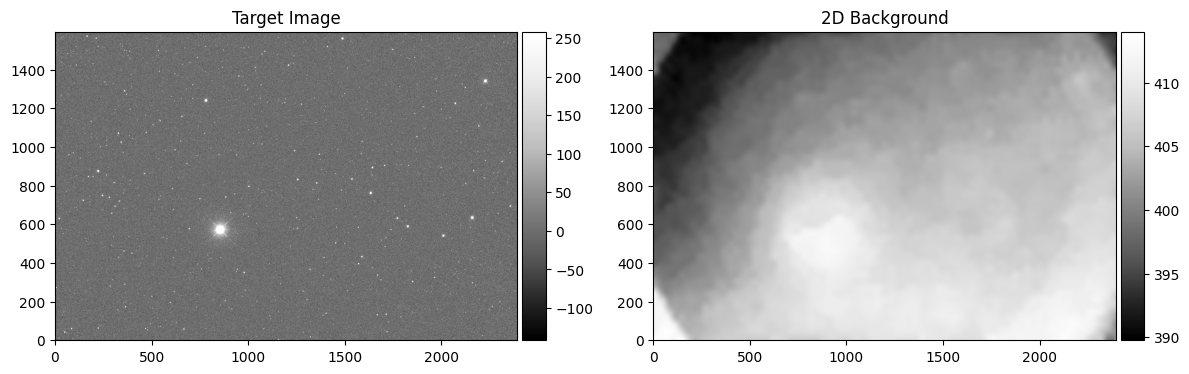

Start SExtractor process...=====================
RUN COMMAND: source-extractor /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/subbkg_calib_7DT14_T00528_20250906_025855_m600_100.fits -c /home/hhchoi1022/ezphot/config/common/sextractor/7DT_C361K_HIGH_1x1.sexconfig -BACK_TYPE MANUAL -SEEING_FWHM 3.19 -PIXEL_SCALE 0.5064013569110675 -PHOT_APERTURES 9.90,13.86,19.80,22.14,28.46 -SATUR_LEVEL 59596.19854736328 -PHOT_AUTOPARAMS 2.5,3.5 -CATALOG_NAME /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits.cat -WEIGHT_GAIN N -WEIGHT_IMAGE /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits.bkgrms -WEIGHT_TYPE MAP_RMS 
SExtractor process finished=====================
Output path: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits.cat
Saved: /home/h

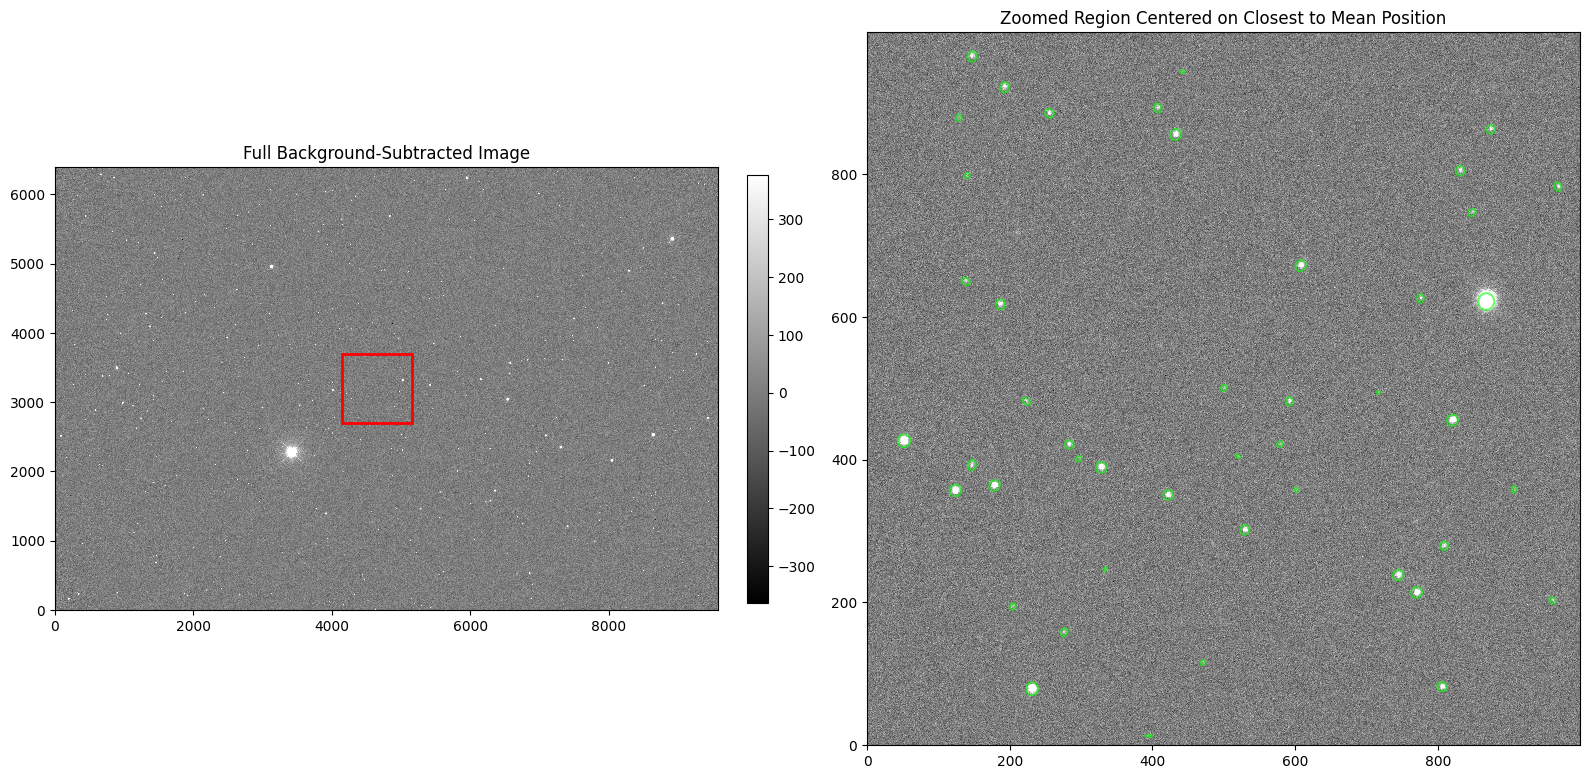

[REMOVE] /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/subbkg_calib_7DT14_T00528_20250906_025855_m600_100.fits
[REMOVE] /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/subbkg_calib_7DT14_T00528_20250906_025855_m600_100.fits.status
[REMOVE] /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/subbkg_calib_7DT14_T00528_20250906_025855_m600_100.fits.info


Catalog( N_selected/N_sources = None/2440, is_exists=True, catalog_type=all, path=/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits.cat)

In [3]:
from ezphot.methods import AperturePhotometry
target_catalog = target_img.catalog # You can access to the catalog after running aperture photometry with save = True

aperturephot = AperturePhotometry()
aperturephot.sex_photometry(
    target_img = target_img,
    target_bkg = target_img.bkgmap,
    target_bkgrms = target_img.bkgrms,
    target_mask = None,
    detection_sigma = 5,
    aperture_dismater_arcsec = [5, 7, 10],
    aperture_dismater_seeing = [3.5, 4.5],
    kron_factor = 2.5,
    save = True, # To load the catalog as attribute of target_img instance, save = True is required.
    verbose = True,
    visualize = True,
    save_fig = False,
)

### 2.2. Run Calibration

Use `PhotometricCalibration` to calibrate your catalog and update the image headers.

**Process:**
1. Load reference catalog from archive
2. Match reference sources to target catalog
3. Select isolated point sources using quality criteria
4. Calculate zero points for each aperture
5. Update catalog and image headers

**Updated Headers:**
- `SEEING`, `SKYSIG`, `ZP_*` (zero points)

**Updated Columns:**
- `MAG_APER` → `MAGSKY_APER`
- `MAG_APER_1` → `MAGSKY_APER_1`
- etc. 


In [4]:
from ezphot.methods import PhotometricCalibration
photcal = PhotometricCalibration()
photcal.help()

Help for PhotometricCalibration

Public methods:
- apply_color_terms(target_img: Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.referenceimage.ReferenceImage], target_catalog: ezphot.dataobjects.catalog.Catalog, comparison_catalog: ezphot.dataobjects.catalog.Catalog, max_distance_second: float = 1.0, save: bool = True, verbose: bool = False)
- apply_mag_terms(target_img: Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.referenceimage.ReferenceImage], target_catalog: ezphot.dataobjects.catalog.Catalog, save: bool = True, verbose: bool = False)
- apply_zp(target_img: Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.referenceimage.ReferenceImage], target_catalog: ezphot.dataobjects.catalog.Catalog, save: bool = True, verbose: bool = True)
- determine_reference_mag_range(target_catalog: ezphot.dataobjects.catalog.Catalog, bin_width=0.5, sigma_clip=5, magnitude_key='MAG_AUTO', zp_key='ZP_AUTO', fwhm_key='FWHM_IMAGE', 

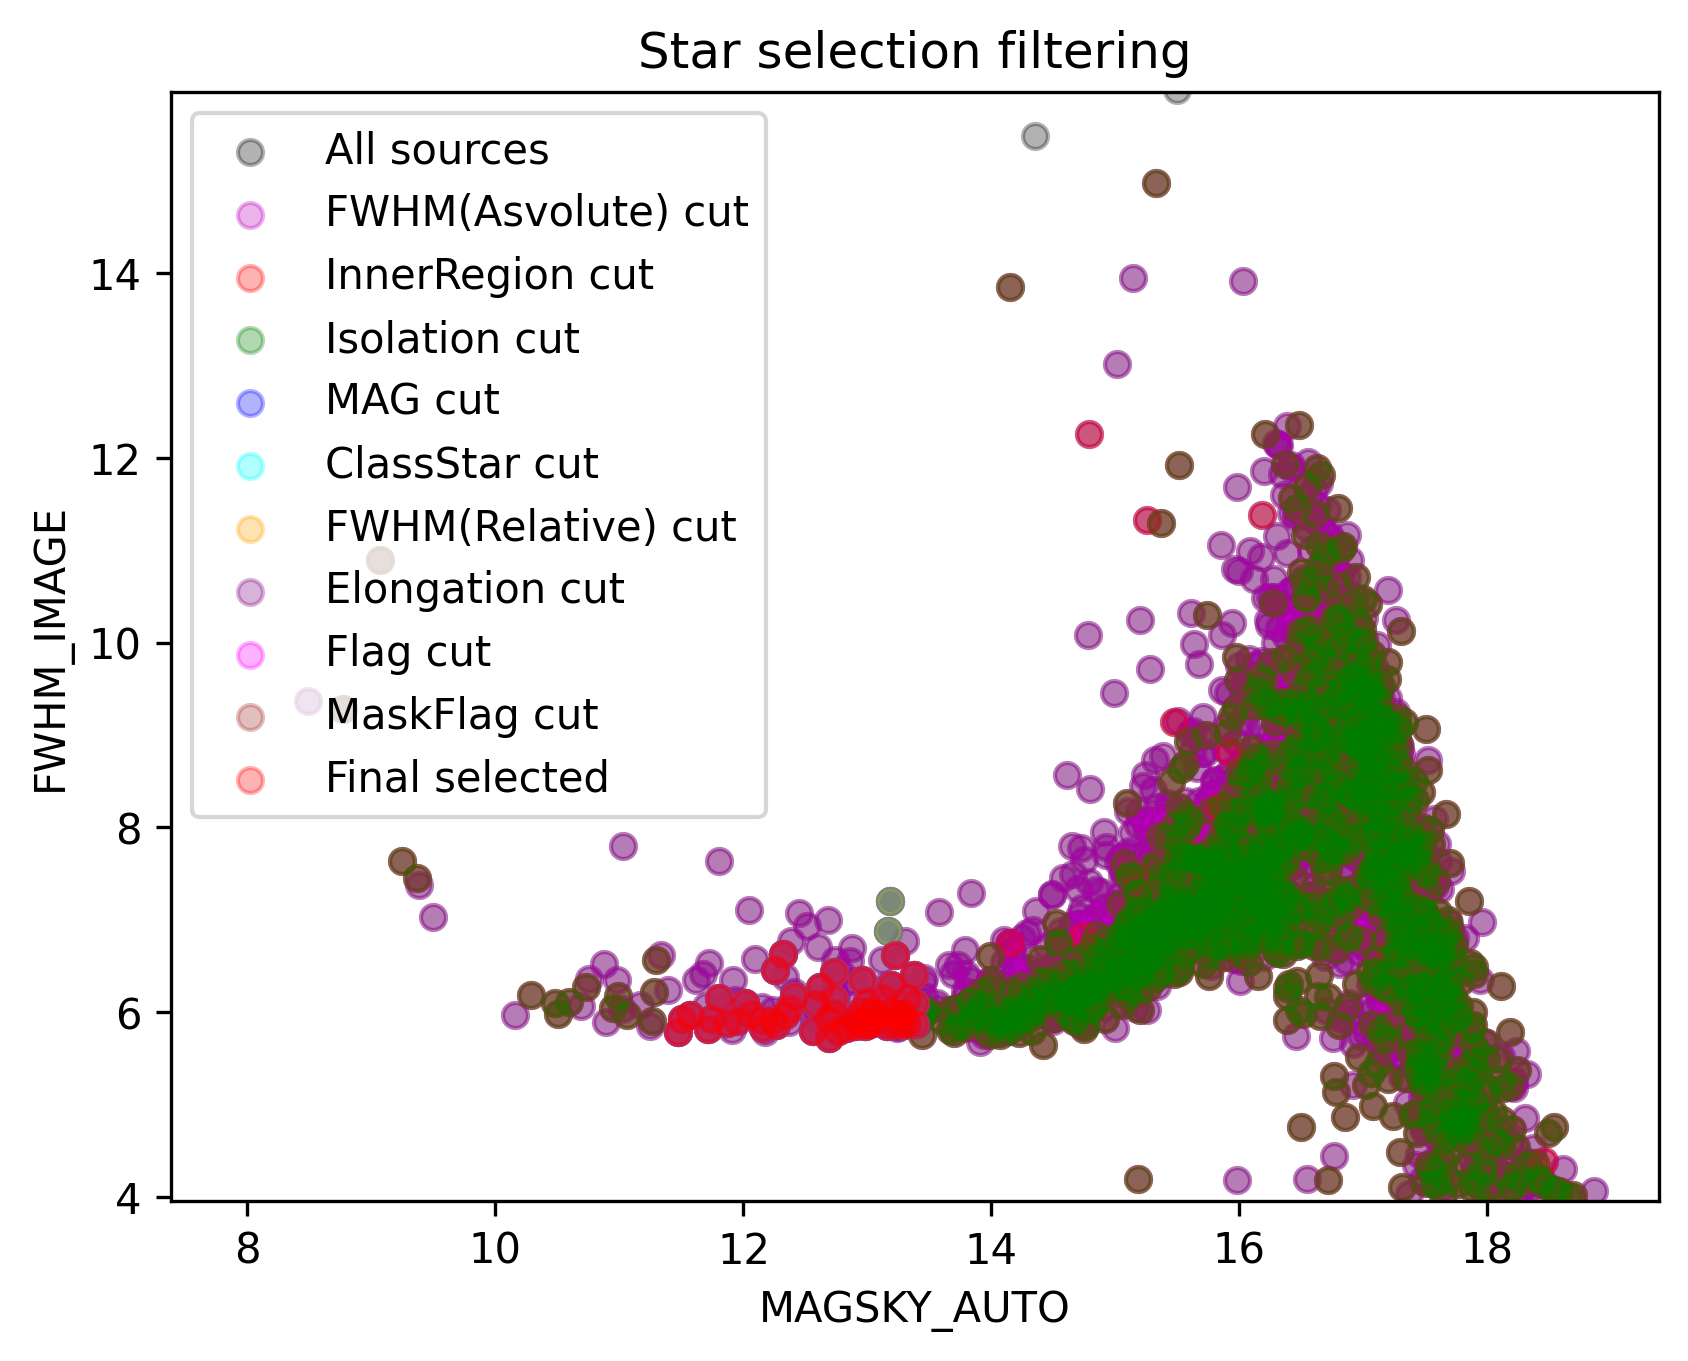

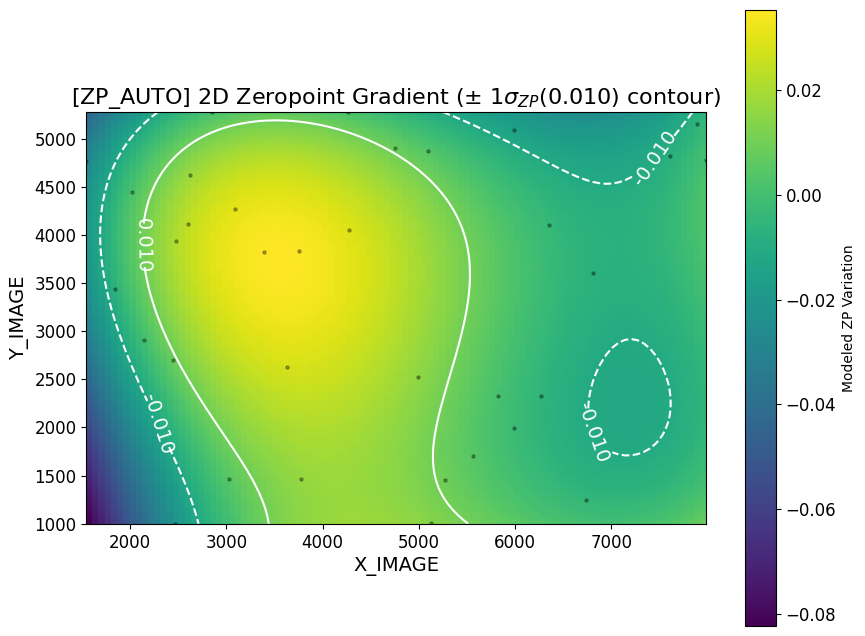

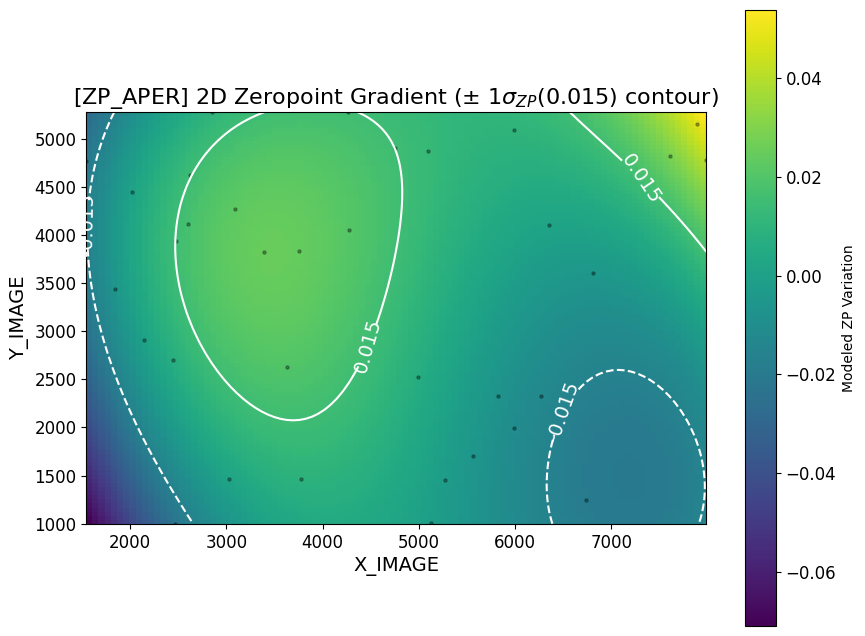

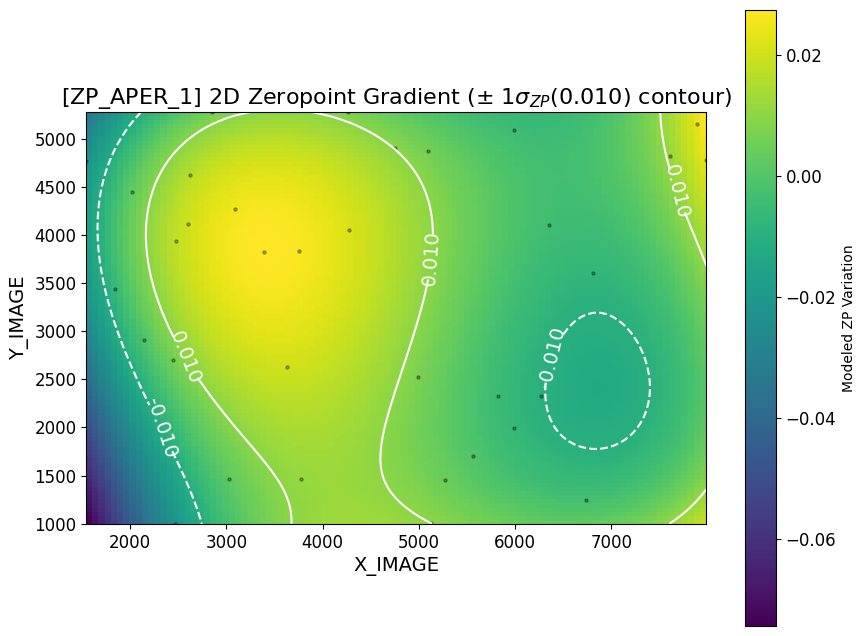

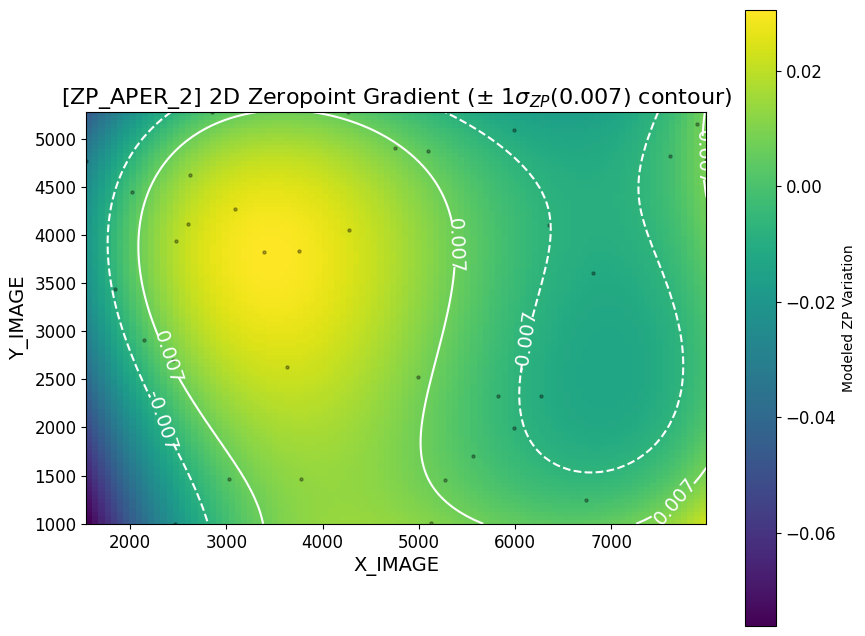

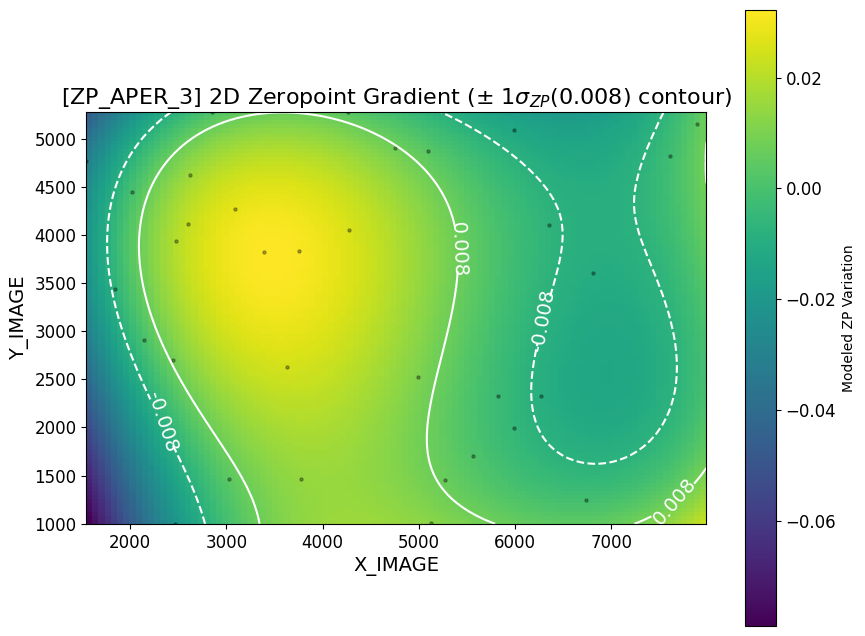

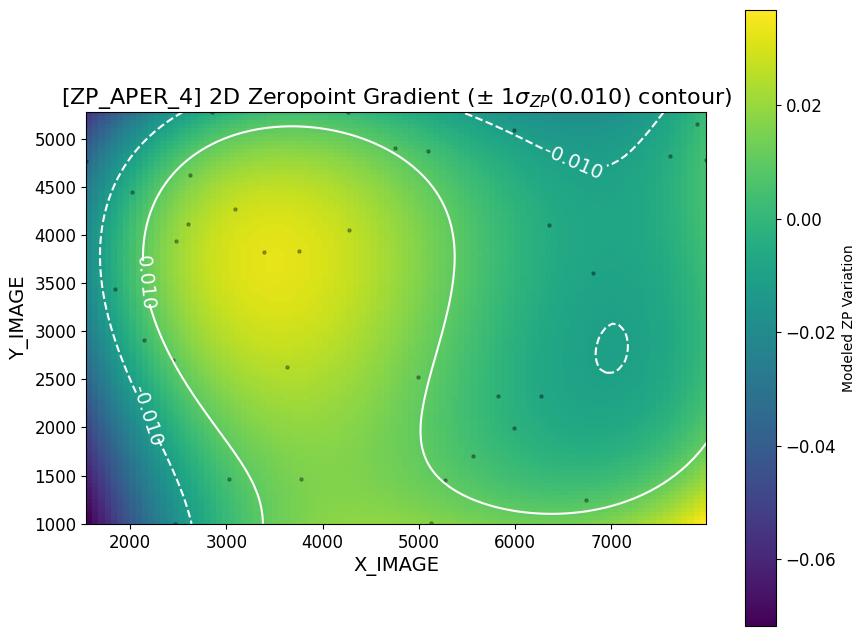

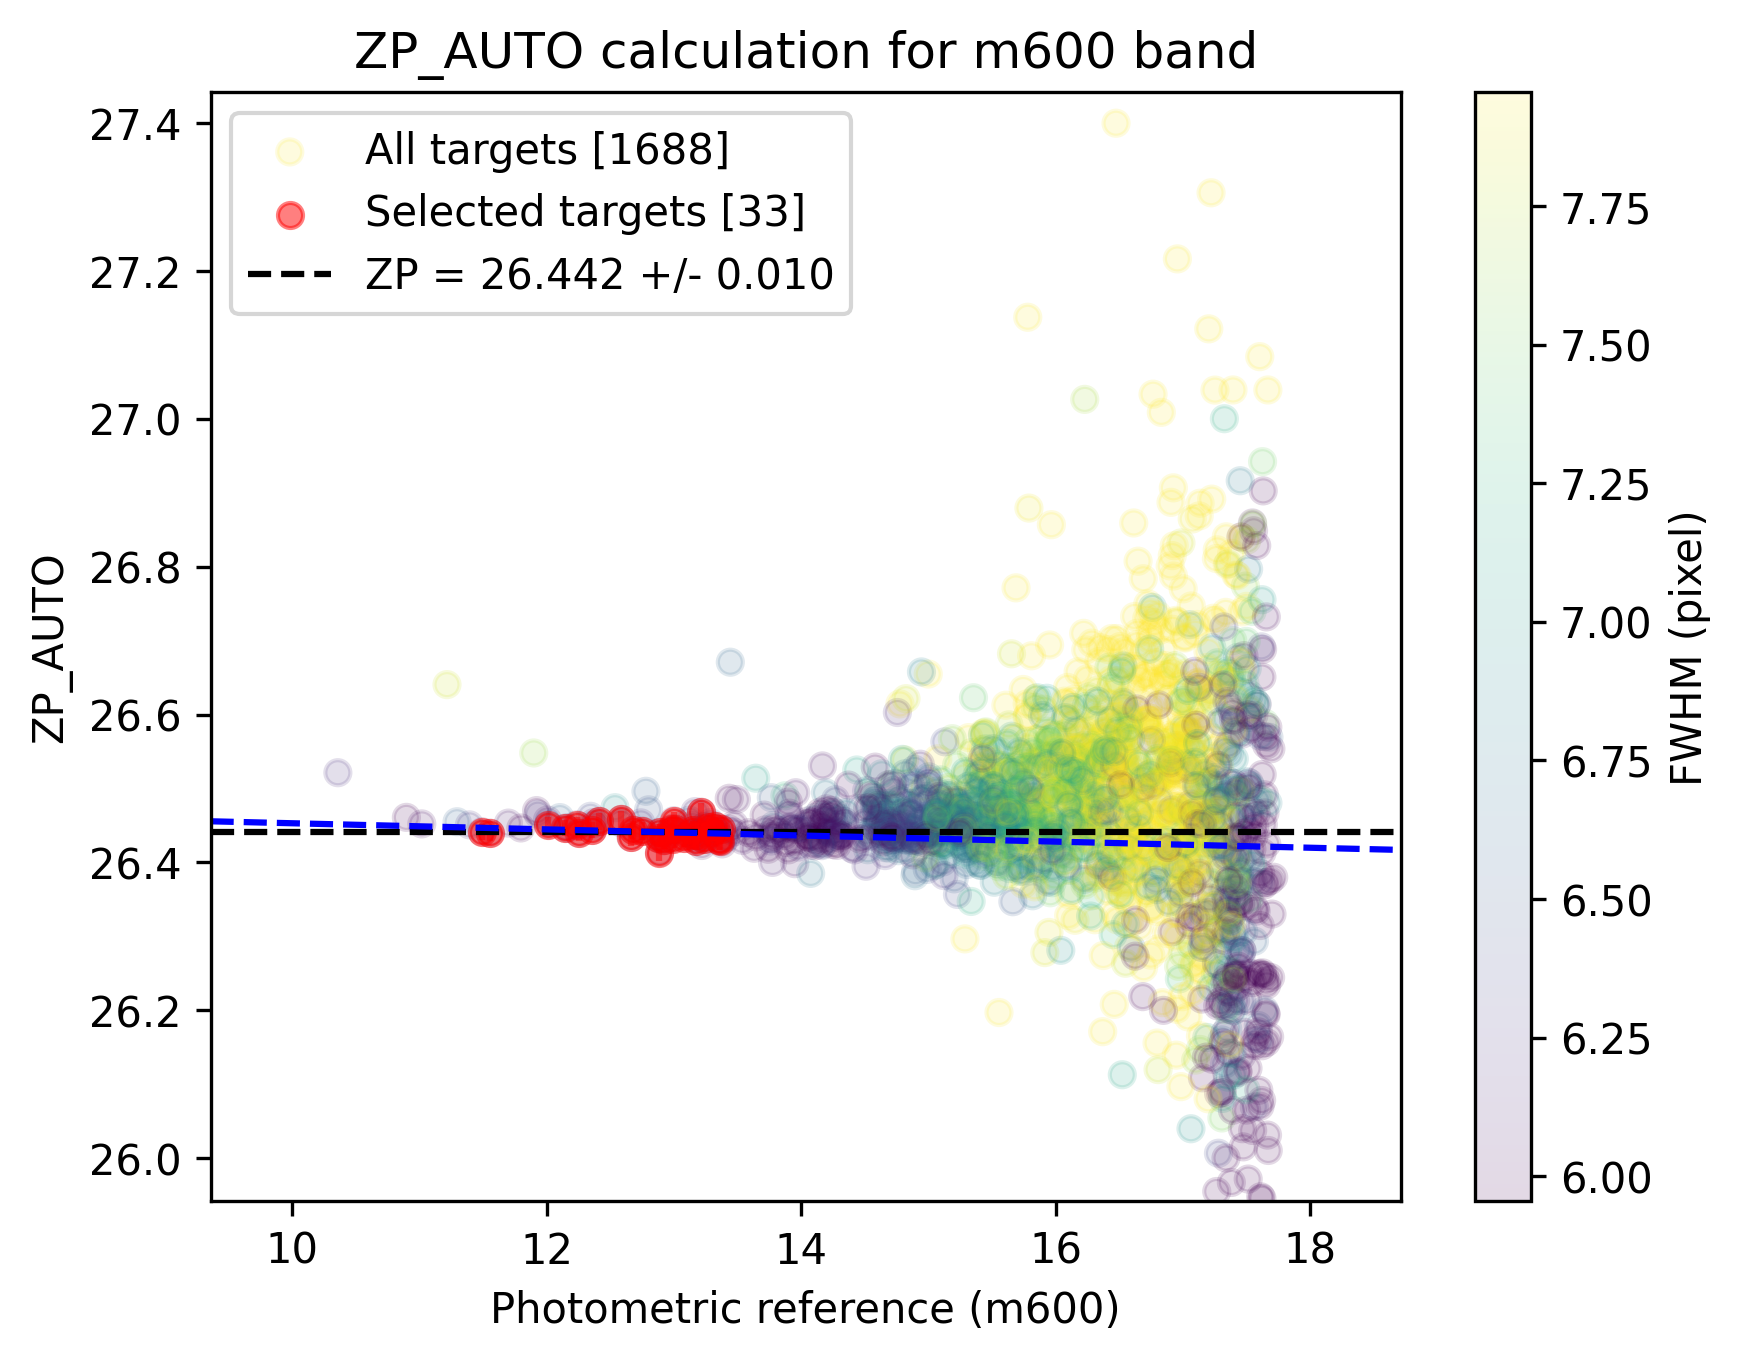

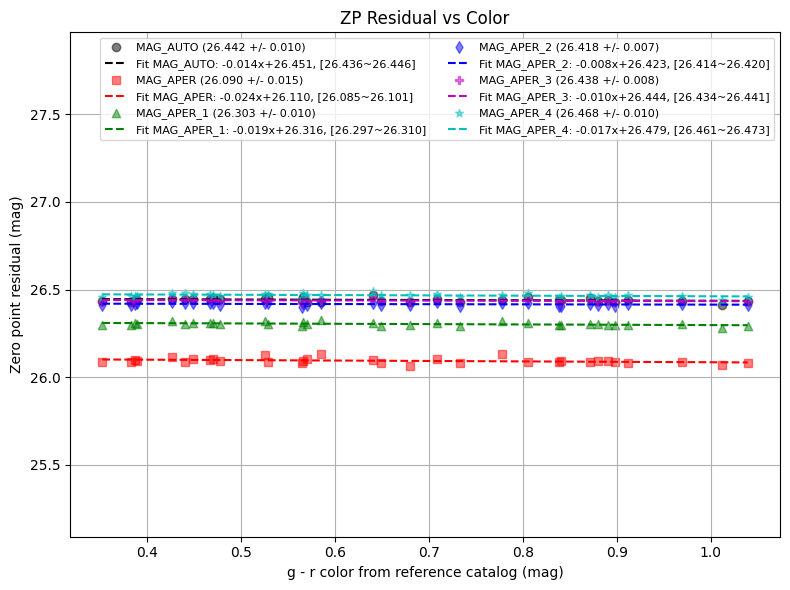

In [5]:
target_img, target_catalog_all, target_catalog_ref = photcal.photometric_calibration(
    target_img = target_img,
    target_catalog = target_catalog,
    catalog_type = 'GAIAXP', # GAIAXP or APASS or PS1 or SMSS or SDSS
    max_distance_second = 1.0,
    calculate_color_terms = True,
    calculate_mag_terms = True,
    mag_lower = 13,
    mag_upper = 15,
    dynamic_mag_range = True,
    classstar_lower = 0.8,
    elongation_upper = 1.7,
    elongation_sigma = 5,
    fwhm_lower = 1,
    fwhm_sigma = 5,
    flag_upper = 1,
    maskflag_upper = 1,
    inner_fraction = 0.7,
    isolation_radius = 10.0,
    magnitude_key = 'MAG_AUTO',
    fwhm_key = 'FWHM_IMAGE',
    x_key = 'X_IMAGE',
    y_key = 'Y_IMAGE',
    classstar_key = 'CLASS_STAR',
    elongation_key = 'ELONGATION',
    flag_key = 'FLAGS',
    maskflag_key = 'IMAFLAGS_ISO',
    save = False,
    verbose = False,
    visualize = True,
    save_fig = False,
    save_refcat = True
)


In [6]:
print('SEEING: ', target_img.header['SEEING'])
print('SKYSIG: ', target_img.header['SKYSIG'])
print('ZP_APER_1: ', target_img.header['ZP_APER_1'])
print('ZP_APER_2: ', target_img.header['ZP_APER_2'])
print('UL5SKY_APER_1: ', target_img.header['UL5SKY_APER_1'])
print('UL5SKY_APER_2: ', target_img.header['UL5SKY_APER_2'])


SEEING:  3.015620080405407
SKYSIG:  39.7305
ZP_APER_1:  26.302696857378585
ZP_APER_2:  26.41774918536101
UL5SKY_APER_1:  17.837091470084452
UL5SKY_APER_2:  17.564888898102517


In [7]:
target_catalog.data['MAG_AUTO', 'MAGSKY_AUTO']

MAG_AUTO,MAGSKY_AUTO
float64,float64
-11.466,14.975660202152492
-11.528,14.91366020215249
-11.3204,15.121260202152492
-13.6693,12.772360202152491
-9.6095,16.83216020215249
-9.1888,17.25286020215249
-10.2136,16.22806020215249
-9.7048,16.736860202152492
-11.2518,15.189860202152492


In [9]:
# Run for all target_imglist with multiprocessing
from multiprocessing import Pool
from tqdm import tqdm

def photometriccalibration(target_img):    
    photcal.photometric_calibration(
        target_img = target_img,
        target_catalog = target_img.catalog,
        catalog_type = 'GAIAXP', # GAIAXP or APASS or PS1 or SMSS or SDSS
        max_distance_second = 1.0,
        calculate_color_terms = True,
        calculate_mag_terms = True,
        mag_lower = 13,
        mag_upper = 15,
        dynamic_mag_range = True,
        classstar_lower = 0.8,
        elongation_upper = 1.7,
        elongation_sigma = 5,
        fwhm_lower = 1,
        fwhm_sigma = 5,
        flag_upper = 1,
        maskflag_upper = 1,
        inner_fraction = 0.7,
        isolation_radius = 10.0,
        magnitude_key = 'MAG_AUTO',
        fwhm_key = 'FWHM_IMAGE',
        x_key = 'X_IMAGE',
        y_key = 'Y_IMAGE',
        classstar_key = 'CLASS_STAR',
        elongation_key = 'ELONGATION',
        flag_key = 'FLAGS',
        maskflag_key = 'IMAFLAGS_ISO',
        save = True,
        verbose = False,
        visualize = False,
        save_fig = False,
        save_refcat = True
    )
    
# for target_img in tqdm(target_imglist, desc="Photometric Calibration..."):
#     photometriccalibration(target_img)
    
with Pool(processes = 16) as pool:
    # Use tqdm with imap to show progress
    list(tqdm(pool.imap(photometriccalibration, target_imglist), 
              total=len(target_imglist), 
              desc="Photometric Calibration..."))

Photometric Calibration...: 100%|██████████| 90/90 [00:20<00:00,  4.31it/s]


After calculation of Catalog with save option as "TRUE", you can access to the catalogs easily from `DataBrowser`

In [13]:
databrowser.objname = 'T00528'
databrowser.filter = 'm600'
target_catalogset = databrowser.search('*.cat', 'catalog')
target_cataloglist = target_catalogset.target_catalogs

[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/*/m600/*.cat'


Loading Catalogs: 100%|██████████| 90/90 [00:00<00:00, 110.93it/s]


In [16]:
for target_catalog in target_cataloglist[:10]:
    print('Number of sources: ', len(target_catalog.data))

Number of sources:  2015
Number of sources:  2173
Number of sources:  3128
Number of sources:  2295
Number of sources:  3270
Number of sources:  2673
Number of sources:  2619
Number of sources:  3812
Number of sources:  3237
Number of sources:  3251
